# How to choose the right connectivity threshold for STTC graphs


In [1]:
import matplotlib.pyplot as plt
from ngmd.config import load_config
import nb_plotting
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity

from ngmd import dataset, graphs, plotting, sttc, timeseries

%reload_ext autoreload
%autoreload 2

# Dataset path as a global variable. Remember to set the correct path to the
# dataset in `configs/config.yaml`
CONFIG = load_config()
DATA_DIR = CONFIG["paths"]["data_dir"]
ANALYSIS_DIR = os.path.join(DATA_DIR, "analysis_files")


As usual, let us create the dataset object


In [2]:
animal_dataset = dataset.AnimalDataset(DATA_DIR)

Now, let us define some global variables for this notebook


In [3]:
DT = CONFIG["precompute_sttc_arrays"]["dt"]  # seconds
XRANGE = tuple(CONFIG["sttc_analysis"]["xrange"])  # range of absolute STTC values
BINS = 100
K = 3
PCTILE = 98.5
NUM_TRIALS = CONFIG["sttc_analysis"]["num_trials"]
BANDWIDTH = CONFIG["sttc_analysis"]["kde_bandwidth"]

## Load sample neural activity data


We need to find a procedure that works well for sessions of low and high activity levels


In [4]:
def plot_traces_side_by_side(
    binarized_traces_low_activity,
    session_low_activity,
    binarized_traces_high_activity,
    session_high_activity,
):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    plotting.plot_binary_traces(
        binarized_traces_low_activity,
        session_low_activity.sample_rate,
        axs[0],
    )
    axs[0].set_title(
        "{}/{} (low activity)".format(
            session_low_activity.animal_id, session_low_activity.date
        )
    )
    plotting.plot_binary_traces(
        binarized_traces_high_activity,
        session_high_activity.sample_rate,
        axs[1],
    )
    axs[1].set_title(
        "{}/{} (high activity)".format(
            session_high_activity.animal_id, session_high_activity.date
        )
    )
    return fig, axs

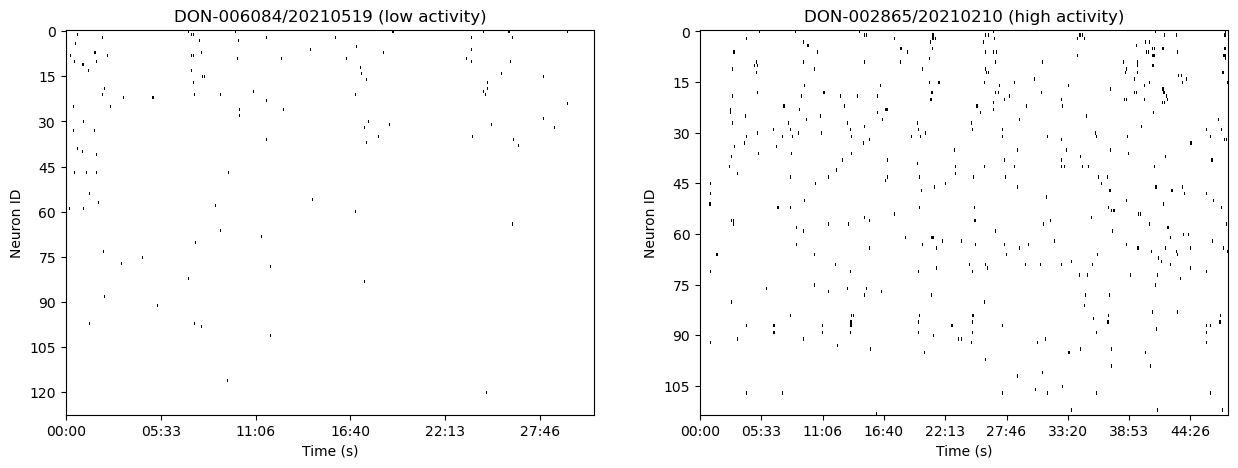

In [5]:
# Load a session with little activity and one with high activity
session_low_activity = animal_dataset.get_animal_from_id(
    "DON-006084"
).get_session_from_date("20210519")

session_high_activity = animal_dataset.get_animal_from_id(
    "DON-002865"
).get_session_from_date("20210210")

# Load the binarized traces of each session
binarized_traces_low_activity = animal_dataset.load_traces_from_good_rois(
    session_low_activity
)
binarized_traces_high_activity = animal_dataset.load_traces_from_good_rois(
    session_high_activity
)

# Scatter plot them side-by-side
fig, axs = plot_traces_side_by_side(
    binarized_traces_low_activity,
    session_low_activity,
    binarized_traces_high_activity,
    session_high_activity,
)
plt.show()

## Distributions of STTC values


In [6]:
def plot_distributions_side_by_side(
    sttc_values_low_activity,
    session_low_activity,
    sttc_values_high_activity,
    session_high_activity,
):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    nb_plotting.plot_histogram(
        sttc_values_low_activity,
        bins=BINS,
        range=XRANGE,
        ax=axs[0],
        log=True,
    )
    nb_plotting.draw_fence_line(sttc_values_low_activity, axs[0], k=K)
    nb_plotting.draw_percentile_line(
        sttc_values_low_activity, PCTILE, axs[0], ha="left"
    )
    nb_plotting.draw_percentile_line(sttc_values_low_activity, 100, axs[0], ha="left")
    axs[0].set_title(
        "{}/{} (low activity): STTC values".format(
            session_low_activity.animal_id, session_low_activity.date
        )
    )

    nb_plotting.plot_histogram(
        sttc_values_high_activity,
        bins=BINS,
        range=XRANGE,
        ax=axs[1],
        log=True,
    )
    nb_plotting.draw_fence_line(sttc_values_high_activity, axs[1], k=K)
    nb_plotting.draw_percentile_line(
        sttc_values_high_activity, PCTILE, axs[1], ha="left"
    )
    nb_plotting.draw_percentile_line(sttc_values_high_activity, 100, axs[1], ha="left")
    axs[1].set_title(
        "{}/{} (high activity): STTC values".format(
            session_high_activity.animal_id, session_high_activity.date
        )
    )

    return fig, axs

In [7]:
def overlay_kde_curves(values_low_activity, values_high_activity, axs, **kwargs):
    kernel = kwargs.pop("kernel", "exponential")
    bandwidth = kwargs.pop("bandwidth", BANDWIDTH)

    # Remove NaNs
    values_low_activity = values_low_activity[~np.isnan(values_low_activity)]
    values_high_activity = values_high_activity[~np.isnan(values_high_activity)]

    # Fit KDE
    kde_low_activity = KernelDensity(kernel=kernel, bandwidth=bandwidth, **kwargs).fit(
        values_low_activity.reshape(-1, 1)
    )
    kde_high_activity = KernelDensity(kernel=kernel, bandwidth=bandwidth, **kwargs).fit(
        values_high_activity.reshape(-1, 1)
    )

    # Score
    x = np.linspace(*XRANGE, 1000)
    y_low_activity = np.exp(kde_low_activity.score_samples(x.reshape(-1, 1)))
    y_high_activity = np.exp(kde_high_activity.score_samples(x.reshape(-1, 1)))

    # Overlay
    color = plotting.UnibasColors().mint
    axs[0].plot(x, y_low_activity, color=color, label="KDE")
    axs[1].plot(x, y_high_activity, color=color, label="KDE")

    return kde_low_activity, kde_high_activity

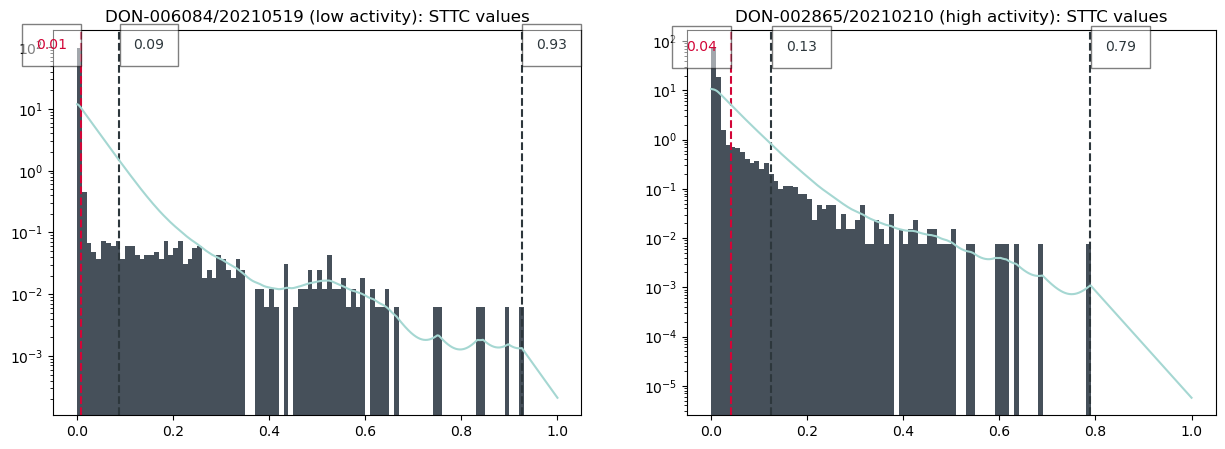

In [8]:
# Plot histogram of STTC values
original_sttc_mat_low_activity = sttc.matrix_spike_time_tiling_coefficient(
    binarized_traces_low_activity, session_low_activity.sample_rate, dt=DT
)
original_sttc_mat_high_activity = sttc.matrix_spike_time_tiling_coefficient(
    binarized_traces_high_activity, session_high_activity.sample_rate, dt=DT
)

# Flatten arrays and get the absolute values
original_values_low_activity = np.abs(
    np.triu(original_sttc_mat_low_activity, k=1).flatten()
)
original_values_high_activity = np.abs(
    np.triu(original_sttc_mat_high_activity, k=1).flatten()
)

# Plot the distributions side-by-side
fig, axs = plot_distributions_side_by_side(
    original_values_low_activity,
    session_low_activity,
    original_values_high_activity,
    session_high_activity,
)
kde_original_low_activity, kde_original_high_activity = overlay_kde_curves(
    original_values_low_activity, original_values_high_activity, axs
)
plt.show()

In [9]:
def print_num_above(values, threshold):
    n_values_above = np.sum(np.abs(values) > threshold)
    pct = 100 * n_values_above / len(values)
    print(
        "\t{} pairs ({:.2f}%) with value above {:.2f}".format(
            n_values_above, pct, threshold
        )
    )

In [10]:
pctile_value = np.nanpercentile(original_values_low_activity, PCTILE)
max_value = np.nanmax(original_values_low_activity)
summary_low_activity = pd.DataFrame(
    {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
    index=["Original STTC"],
)
print("Low activity:")
print_num_above(original_values_low_activity, pctile_value)

pctile_value = np.nanpercentile(original_values_high_activity, PCTILE)
max_value = np.nanmax(original_values_high_activity)
summary_high_activity = pd.DataFrame(
    {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
    index=["Original STTC"],
)
print("High activity:")
print_num_above(original_values_high_activity, pctile_value)

Low activity:
	246 pairs (1.50%) with value above 0.09
High activity:
	195 pairs (1.50%) with value above 0.13


## Creating surrogate binarized traces and computing STTC value distributions


### Time shuffles: distribution of values in the whole array


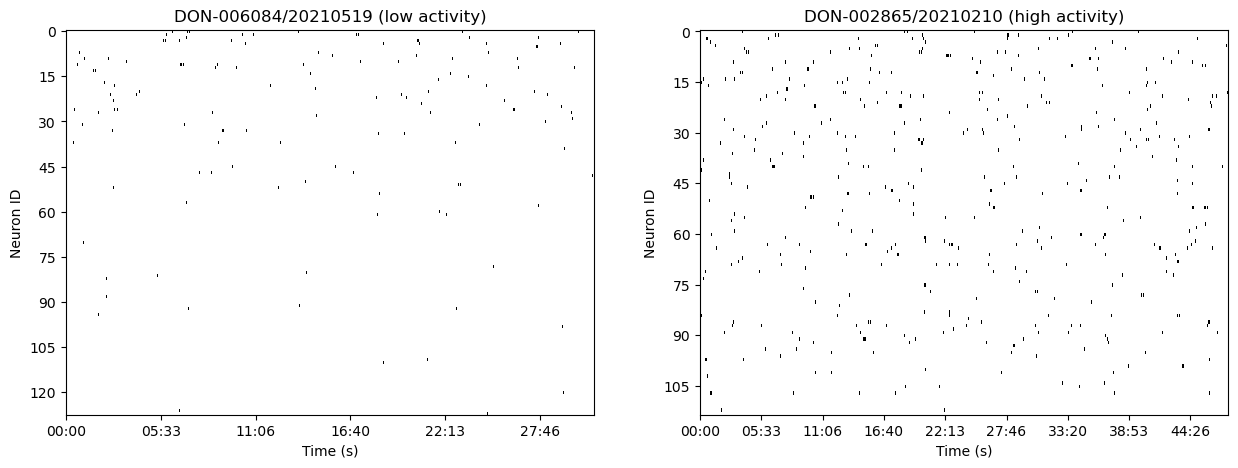

In [11]:
surrogates_low_activity = timeseries.make_surrogate_traces(
    binarized_traces_low_activity, method="time_shuffle"
)
surrogates_high_activity = timeseries.make_surrogate_traces(
    binarized_traces_high_activity, method="time_shuffle"
)

# Scatter plot them side-by-side
fig, axs = plot_traces_side_by_side(
    surrogates_low_activity,
    session_low_activity,
    surrogates_high_activity,
    session_high_activity,
)
plt.show()

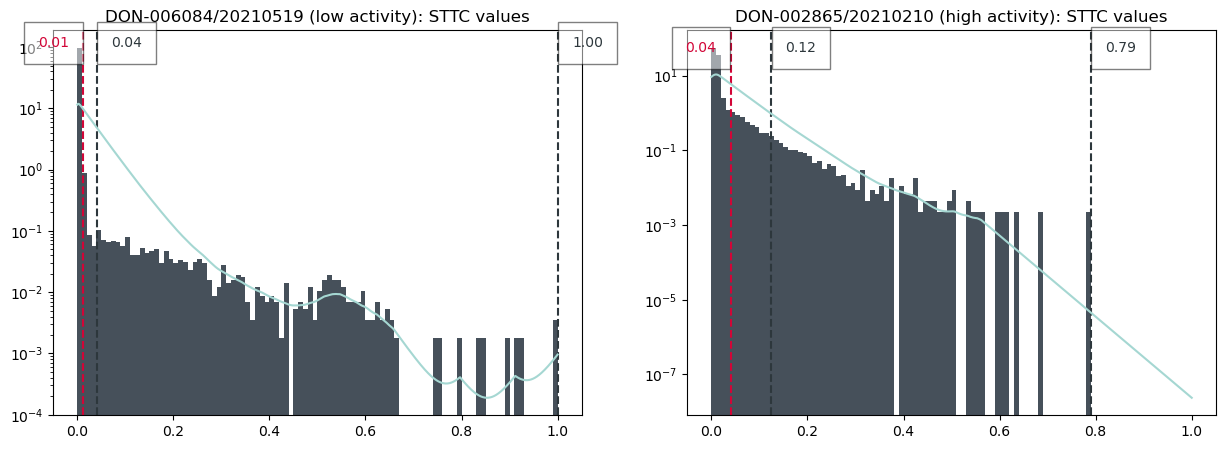

In [12]:
values_low_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_low_activity,
    session_low_activity.sample_rate,
    method="time_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_low_activity = np.abs(values_low_activity).flatten()

values_high_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_high_activity,
    session_high_activity.sample_rate,
    method="time_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_high_activity = np.abs(values_high_activity).flatten()

# Plot the distributions side-by-side
fig, axs = plot_distributions_side_by_side(
    np.concatenate([original_values_low_activity, values_low_activity]),
    session_low_activity,
    np.concatenate([original_values_high_activity, values_high_activity]),
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

In [13]:
pctile_value = np.nanpercentile(values_low_activity, PCTILE)
max_value = np.nanmax(values_low_activity)
summary_low_activity = pd.concat(
    [
        summary_low_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Time Shuffle STTC"],
        ),
    ]
)
print("Low activity:")
print_num_above(original_values_low_activity, pctile_value)

pctile_value = np.nanpercentile(values_high_activity, PCTILE)
max_value = np.nanmax(values_high_activity)
summary_high_activity = pd.concat(
    [
        summary_high_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Time Shuffle STTC"],
        ),
    ]
)
print("High activity:")
print_num_above(original_values_high_activity, pctile_value)

Low activity:
	306 pairs (1.87%) with value above 0.03
High activity:
	199 pairs (1.53%) with value above 0.12


### Time shuffles: distribution of values in an ROI pair


What if we compare `STTC[i,j]` only with the surrogate values obtained from time-shuffling the ROIs `i` and `j`?


STTC[1, 2] = 0.13


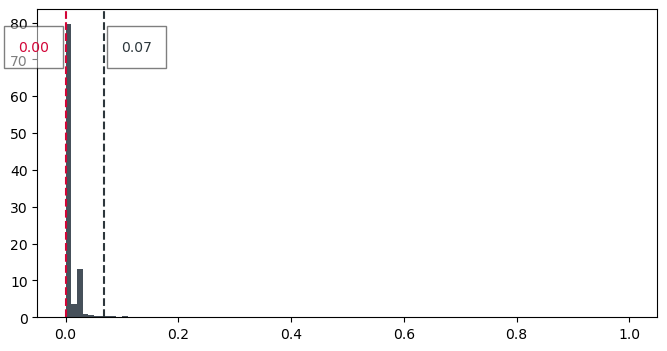

In [14]:
rois = [1, 2]
print(
    "STTC[{}, {}] = {:.2f}".format(
        rois[0], rois[1], original_sttc_mat_high_activity[rois[0], rois[1]]
    )
)
sttc_values = []
n_trials = 1000
for i in range(n_trials):
    time_shuffle_surrogate = timeseries.make_surrogate_traces(
        binarized_traces_high_activity[rois, :], method="time_shuffle"
    )
    sttc_mat = sttc.matrix_spike_time_tiling_coefficient(
        time_shuffle_surrogate, session_high_activity.sample_rate, dt=DT
    )
    sttc_values += np.triu(sttc_mat, k=1).flatten().tolist()

values = np.abs(sttc_values)
ax, _, _ = nb_plotting.plot_histogram(values, bins=BINS, range=XRANGE)
nb_plotting.draw_fence_line(values, ax, k=K)
nb_plotting.draw_percentile_line(values, PCTILE, ax, ha="left")
plt.show()

### Pulse shuffles


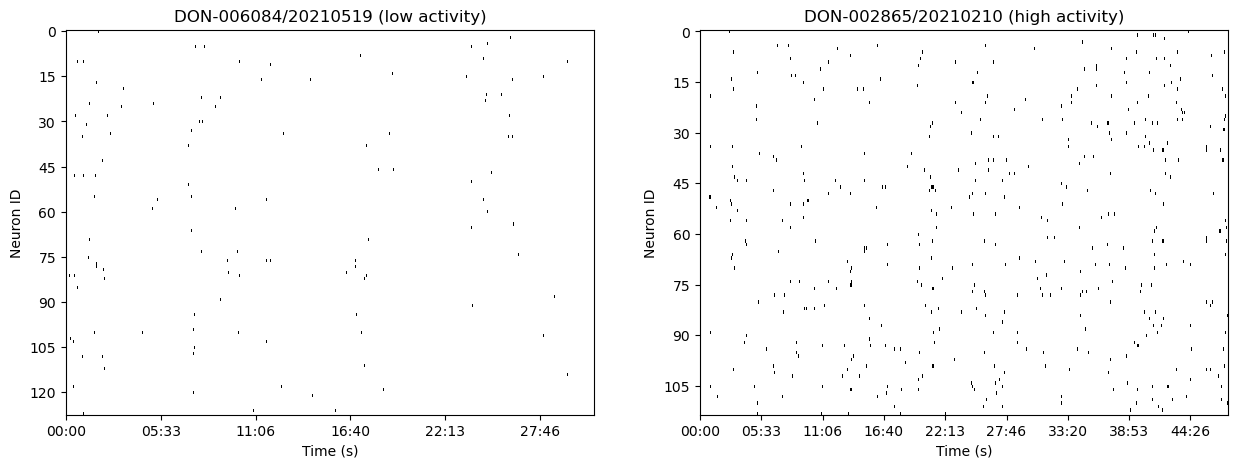

In [15]:
surrogates_low_activity = timeseries.make_surrogate_traces(
    binarized_traces_low_activity, method="pulse_shuffle"
)
surrogates_high_activity = timeseries.make_surrogate_traces(
    binarized_traces_high_activity, method="pulse_shuffle"
)

# Scatter plot them side-by-side
fig, axs = plot_traces_side_by_side(
    surrogates_low_activity,
    session_low_activity,
    surrogates_high_activity,
    session_high_activity,
)
plt.show()

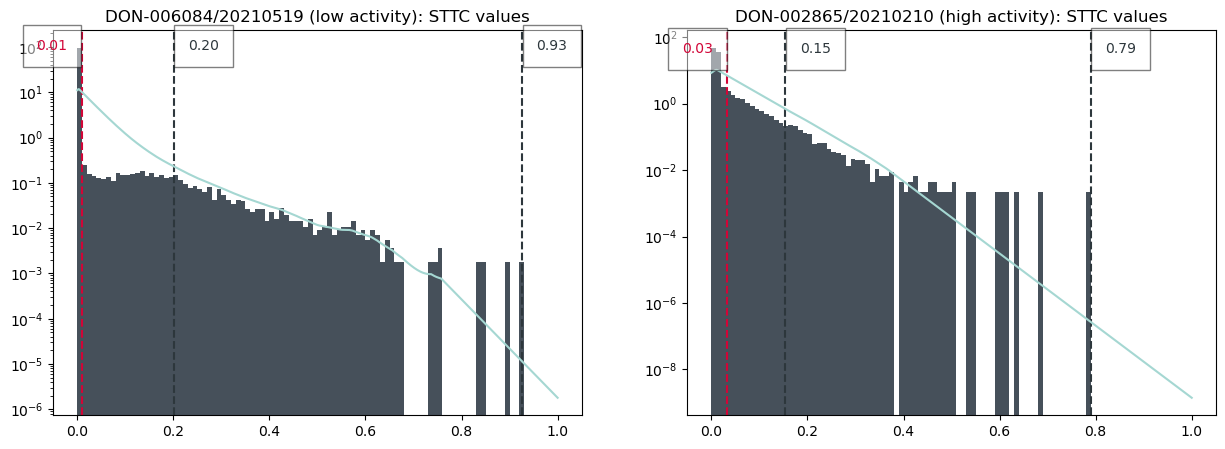

In [16]:
values_low_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_low_activity,
    session_low_activity.sample_rate,
    method="pulse_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_low_activity = np.abs(values_low_activity).flatten()

values_high_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_high_activity,
    session_high_activity.sample_rate,
    method="pulse_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_high_activity = np.abs(values_high_activity).flatten()

# Plot the distributions side-by-side
fig, axs = plot_distributions_side_by_side(
    np.concatenate([original_values_low_activity, values_low_activity]),
    session_low_activity,
    np.concatenate([original_values_high_activity, values_high_activity]),
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

In [17]:
# Save percentiles matrix for later
pulse_shuffles_pctile_mat_low_activity = timeseries.compute_percentiles_matrix(
    original_sttc_mat_low_activity, values_low_activity
)

pulse_shuffles_pctile_mat_high_activity = timeseries.compute_percentiles_matrix(
    original_sttc_mat_high_activity, values_high_activity
)

In [18]:
pctile_value = np.nanpercentile(values_low_activity, PCTILE)
max_value = np.nanmax(values_low_activity)
summary_low_activity = pd.concat(
    [
        summary_low_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Pulse Shuffle STTC"],
        ),
    ]
)
print("Low activity:")
print_num_above(original_values_low_activity, pctile_value)

pctile_value = np.nanpercentile(values_high_activity, PCTILE)
max_value = np.nanmax(values_high_activity)
summary_high_activity = pd.concat(
    [
        summary_high_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Pulse Shuffle STTC"],
        ),
    ]
)
print("High activity:")
print_num_above(original_values_high_activity, pctile_value)

Low activity:
	144 pairs (0.88%) with value above 0.21
High activity:
	143 pairs (1.10%) with value above 0.16


### Time- and pulse-shuffles


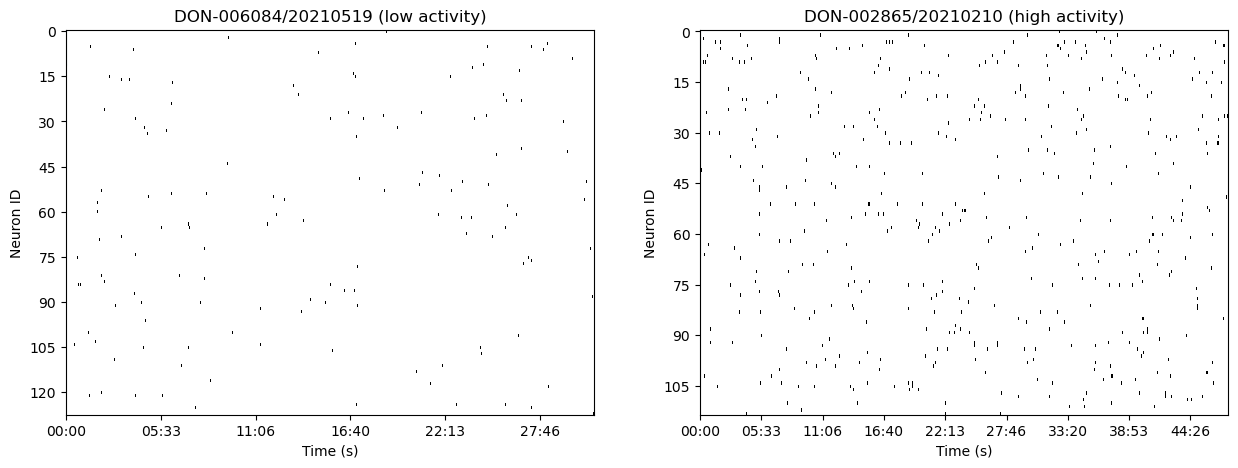

In [19]:
surrogates_low_activity = timeseries.make_surrogate_traces(
    binarized_traces_low_activity, method="time_and_pulse_shuffle"
)
surrogates_high_activity = timeseries.make_surrogate_traces(
    binarized_traces_high_activity, method="time_and_pulse_shuffle"
)

# Scatter plot them side-by-side
fig, axs = plot_traces_side_by_side(
    surrogates_low_activity,
    session_low_activity,
    surrogates_high_activity,
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

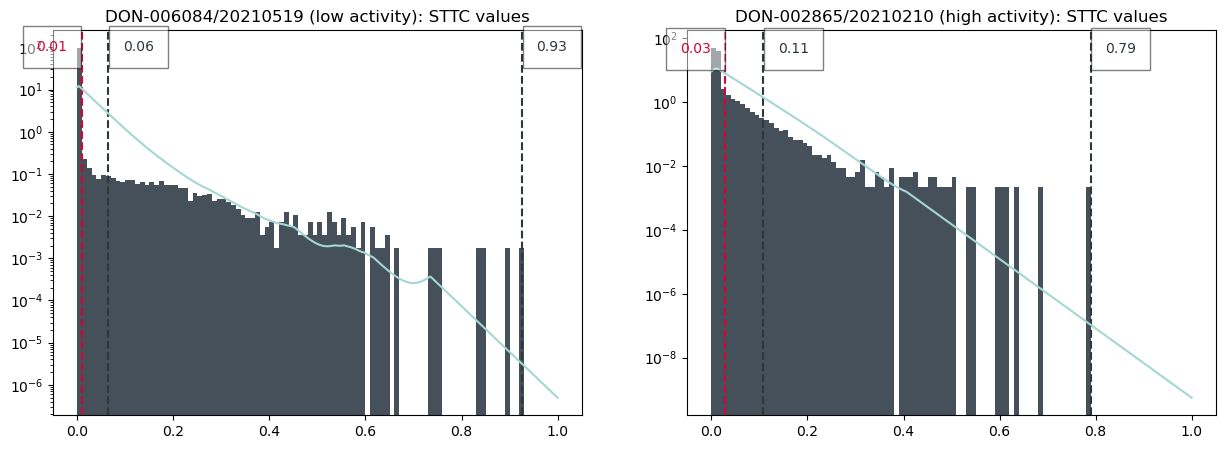

In [20]:
values_low_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_low_activity,
    session_low_activity.sample_rate,
    method="time_and_pulse_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_low_activity = np.abs(values_low_activity).flatten()

values_high_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_high_activity,
    session_high_activity.sample_rate,
    method="time_and_pulse_shuffle",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_high_activity = np.abs(values_high_activity).flatten()

# Plot the distributions side-by-side
fig, axs = plot_distributions_side_by_side(
    np.concatenate([original_values_low_activity, values_low_activity]),
    session_low_activity,
    np.concatenate([original_values_high_activity, values_high_activity]),
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

In [21]:
pctile_value = np.nanpercentile(values_low_activity, PCTILE)
max_value = np.nanmax(values_low_activity)
summary_low_activity = pd.concat(
    [
        summary_low_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Time and Pulse Shuffle STTC"],
        ),
    ]
)
print("Low activity:")
print_num_above(original_values_low_activity, pctile_value)

pctile_value = np.nanpercentile(values_high_activity, PCTILE)
max_value = np.nanmax(values_high_activity)
summary_high_activity = pd.concat(
    [
        summary_high_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Time and Pulse Shuffle STTC"],
        ),
    ]
)
print("High activity:")
print_num_above(original_values_high_activity, pctile_value)

Low activity:
	275 pairs (1.68%) with value above 0.06
High activity:
	282 pairs (2.17%) with value above 0.10


### Poisson surrogates


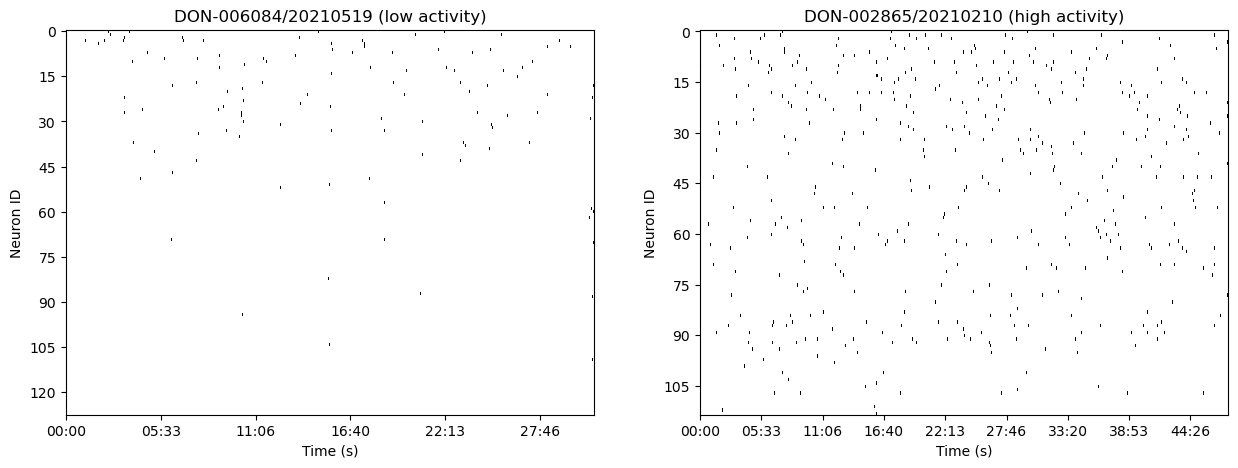

In [22]:
surrogates_low_activity = timeseries.make_surrogate_traces(
    binarized_traces_low_activity, method="poisson"
)
surrogates_high_activity = timeseries.make_surrogate_traces(
    binarized_traces_high_activity, method="poisson"
)

# Scatter plot them side-by-side
fig, axs = plot_traces_side_by_side(
    surrogates_low_activity,
    session_low_activity,
    surrogates_high_activity,
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

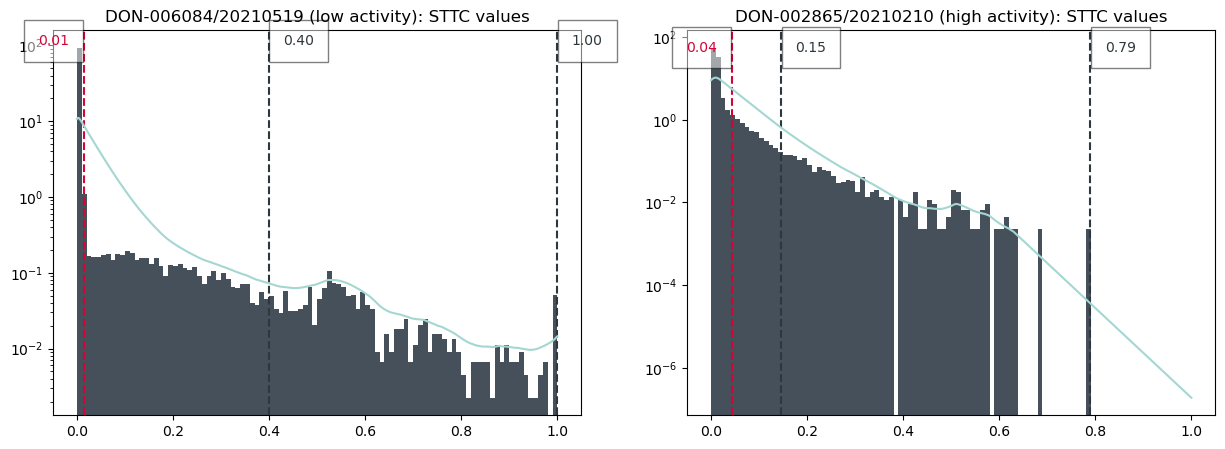

In [23]:
values_low_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_low_activity,
    session_low_activity.sample_rate,
    method="poisson",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_low_activity = np.abs(values_low_activity).flatten()

values_high_activity = timeseries.compile_surrogate_sttc_values(
    binarized_traces_high_activity,
    session_high_activity.sample_rate,
    method="poisson",
    dt=DT,
    num_trials=NUM_TRIALS,
)
values_high_activity = np.abs(values_high_activity).flatten()

# Plot the distributions side-by-side
fig, axs = plot_distributions_side_by_side(
    np.concatenate([original_values_low_activity, values_low_activity]),
    session_low_activity,
    np.concatenate([original_values_high_activity, values_high_activity]),
    session_high_activity,
)
kde_low_activity, kde_high_activity = overlay_kde_curves(
    values_low_activity, values_high_activity, axs
)
plt.show()

In [24]:
pctile_value = np.nanpercentile(values_low_activity, PCTILE)
max_value = np.nanmax(values_low_activity)
summary_low_activity = pd.concat(
    [
        summary_low_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Poisson STTC"],
        ),
    ]
)
print("Low activity:")
print_num_above(original_values_low_activity, pctile_value)

pctile_value = np.nanpercentile(values_high_activity, PCTILE)
max_value = np.nanmax(values_high_activity)
summary_high_activity = pd.concat(
    [
        summary_high_activity,
        pd.DataFrame(
            {"{:.2f}-percentile".format(PCTILE): [pctile_value], "max": [max_value]},
            index=["Poisson STTC"],
        ),
    ]
)
print("High activity:")
print_num_above(original_values_high_activity, pctile_value)

Low activity:
	34 pairs (0.21%) with value above 0.51
High activity:
	153 pairs (1.18%) with value above 0.15


### Conclusions

1. Pulse shuffles provide the most conservative threshold overall
2. Poisson surrogates penalize low activity sessions more
3. Time shuffles between pairs of ROIs is not recommended, because almost all shuffles will produce zero or almost zero overlap. It's more informative to use the whole of shuffles. Still, time shuffle surrogates tend to produce less conservative thresholds than the pulse shuffles.


In [25]:
print("Summary for the low activity trace:")
summary_low_activity.sort_values(
    by="{:.2f}-percentile".format(PCTILE), axis=0, ascending=False
)

Summary for the low activity trace:


,98.50-percentile,max
Poisson STTC,0.514718,1.000000
Pulse Shuffle STTC,0.212983,0.757266
Original STTC,0.087676,0.925850
Time and Pulse Shuffle STTC,0.059289,0.735092
Time Shuffle STTC,0.026258,1.000000


In [26]:
print("Summary for the high activity trace:")
summary_high_activity.sort_values(
    by="{:.2f}-percentile".format(PCTILE), axis=0, ascending=False
)

Summary for the high activity trace:


,98.50-percentile,max
Pulse Shuffle STTC,0.159354,0.366611
Poisson STTC,0.153525,0.629292
Original STTC,0.125114,0.789517
Time Shuffle STTC,0.124293,0.561268
Time and Pulse Shuffle STTC,0.102080,0.405555


## How do the graphs look like when using the percentile threshold?


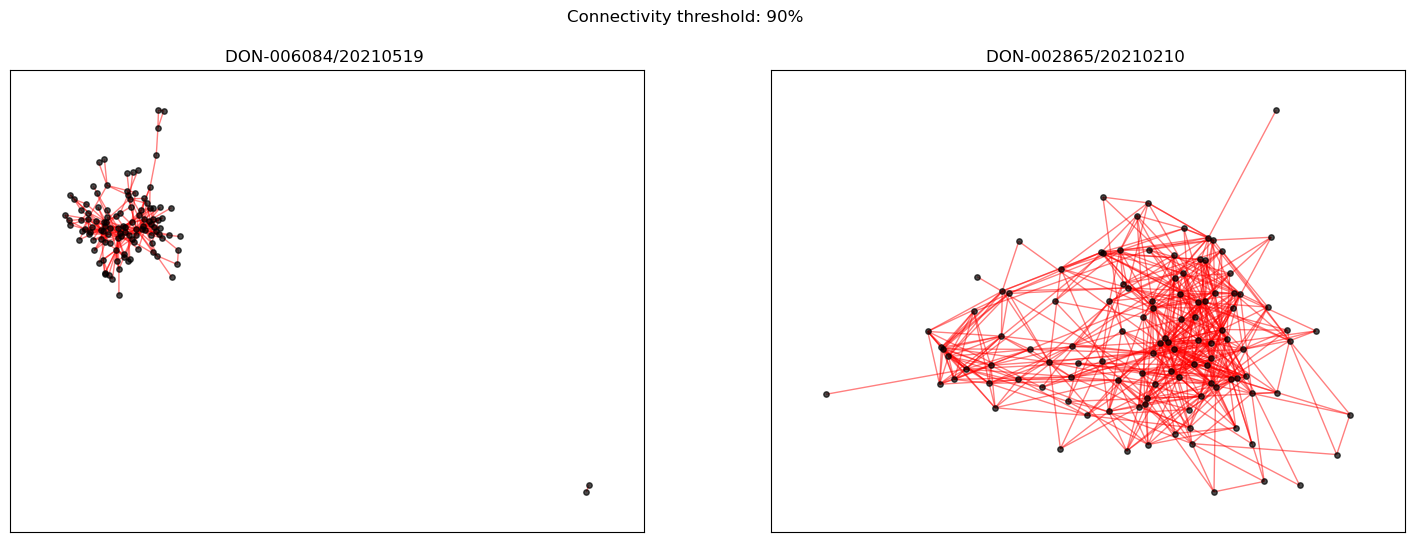

In [27]:
connect_thresh = 90

sg_low_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_low_activity, connect_thresh=connect_thresh
)

sg_high_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_high_activity, connect_thresh=connect_thresh
)

networks = [
    {
        "graph": sg_low_activity,
        "animal_id": session_low_activity.animal_id,
        "session_date": session_low_activity.date,
    },
    {
        "graph": sg_high_activity,
        "animal_id": session_high_activity.animal_id,
        "session_date": session_high_activity.date,
    },
]

fig, axs = plotting.networks_side_by_side(networks, min_cc_size=2)
fig.suptitle("Connectivity threshold: {}%".format(connect_thresh))
plt.show()

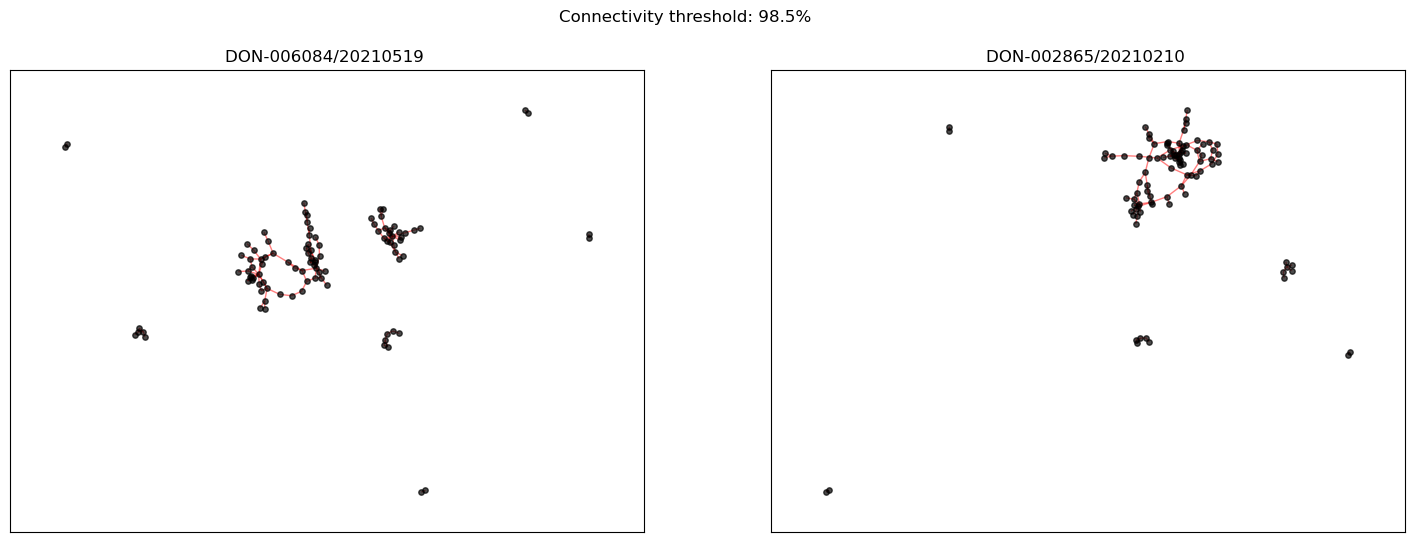

In [28]:
connect_thresh = 98.5

sg_low_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_low_activity, connect_thresh=connect_thresh
)

sg_high_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_high_activity, connect_thresh=connect_thresh
)

networks = [
    {
        "graph": sg_low_activity,
        "animal_id": session_low_activity.animal_id,
        "session_date": session_low_activity.date,
    },
    {
        "graph": sg_high_activity,
        "animal_id": session_high_activity.animal_id,
        "session_date": session_high_activity.date,
    },
]

fig, axs = plotting.networks_side_by_side(networks, min_cc_size=2)
fig.suptitle("Connectivity threshold: {}%".format(connect_thresh))
plt.show()

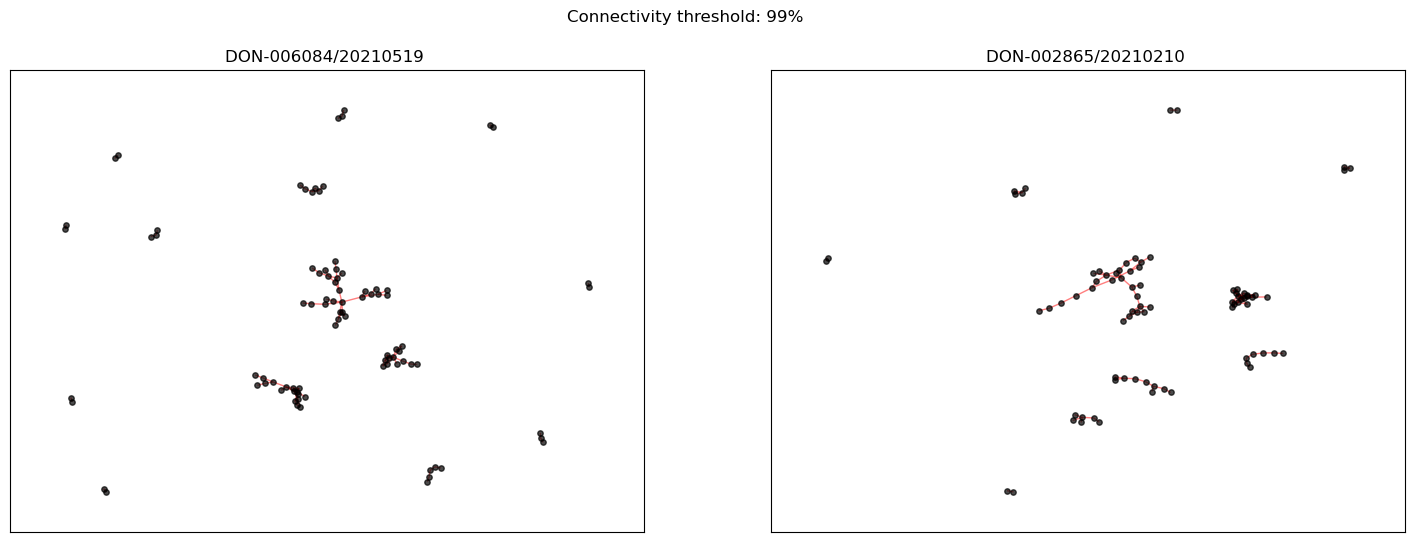

In [29]:
connect_thresh = 99

sg_low_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_low_activity, connect_thresh=connect_thresh
)

sg_high_activity = graphs.SimilarityGraph(
    pulse_shuffles_pctile_mat_high_activity, connect_thresh=connect_thresh
)

networks = [
    {
        "graph": sg_low_activity,
        "animal_id": session_low_activity.animal_id,
        "session_date": session_low_activity.date,
    },
    {
        "graph": sg_high_activity,
        "animal_id": session_high_activity.animal_id,
        "session_date": session_high_activity.date,
    },
]

fig, axs = plotting.networks_side_by_side(networks, min_cc_size=2)
fig.suptitle("Connectivity threshold: {}%".format(connect_thresh))
plt.show()